# Task 2 – Machine Learning & Diagnostic Analysis for Misinformation Detection

**Module:** Data Science for Cyber Security  
**Dataset:** `fake_news_orig.csv` — 12,999 social media articles with metadata  
**Analyst role:** Cyber Security Data Analyst investigating misinformation campaigns

---

This notebook performs a complete diagnostic analysis pipeline on a social media misinformation dataset.  
Each task builds on the previous to construct an end-to-end attacker-profiling and content-classification system:

| Task | Technique | Purpose |
|------|-----------|----------|
| 1 | Correlation Analysis | Identify relationships between engagement metrics |
| 2 | Linear Regression | Model predictive relationships between features |
| 3 | TF-IDF + Naïve Bayes | Classify misinformation type from raw text |
| 4 | Graph Analysis | Map author–article networks and spread patterns |
| 5 | NLP Word Clouds | Visualise dominant vocabulary per misinformation category |

In [8]:
# ─────────────────────────────────────────────────────────────
# Install any missing libraries (safe to re-run)
# ─────────────────────────────────────────────────────────────
!pip install seaborn scipy scikit-learn networkx matplotlib wordcloud nltk --quiet


[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: pip install --upgrade pip


In [9]:
# ─────────────────────────────────────────────────────────────
# Core imports shared across all tasks
# ─────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import seaborn as sns

from scipy import stats

import os

# Set a consistent style for all plots
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})
sns.set_theme(style='whitegrid')

# ─────────────────────────────────────────────────────────────
# Load dataset – on_bad_lines='skip' handles malformed rows
# ─────────────────────────────────────────────────────────────
DATA_PATH = '../data/fake_news_orig.csv'
df = pd.read_csv(DATA_PATH, on_bad_lines='skip')

print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"\nType distribution:\n{df['type'].value_counts()}")
print(f"\nNumeric columns: {df.select_dtypes(include='number').columns.tolist()}")

Dataset shape: (12999, 20)
Columns: ['uuid', 'ord_in_thread', 'author', 'published', 'title', 'text', 'language', 'crawled', 'site_url', 'country', 'domain_rank', 'thread_title', 'spam_score', 'main_img_url', 'replies_count', 'participants_count', 'likes', 'comments', 'shares', 'type']

Type distribution:
type
bs            11492
bias            443
conspiracy      430
hate            246
satire          146
state           121
junksci         102
fake             19
Name: count, dtype: int64

Numeric columns: ['ord_in_thread', 'domain_rank', 'spam_score', 'replies_count', 'participants_count', 'likes', 'comments', 'shares']


---
## Task 1 – Correlation Matrix Analysis (3 marks)

### Technique: Pearson Correlation

**What it does:** A correlation matrix computes the pairwise Pearson correlation coefficient *r* between every pair of numerical features. Values range from −1 (perfect negative linear relationship) to +1 (perfect positive linear relationship); 0 means no linear relationship.

**Why appropriate here:** Social media engagement metrics (likes, shares, replies, comments) are likely to co-vary — high-engagement misinformation posts tend to attract multiple forms of interaction simultaneously. Identifying these co-dependencies helps analysts understand which metrics signal coordinated amplification campaigns.

**Cyber-security context:** High correlation between *shares* and *likes*, for example, may indicate bot-driven coordinated sharing — a hallmark of state-sponsored disinformation operations. The correlation matrix provides an efficient first pass over all metric relationships before deeper modelling.

> **Technique reference:** The Pearson correlation coefficient was introduced in [Pearson, 1895]. Pandas `DataFrame.corr()` is used for computation [McKinney, 2010].

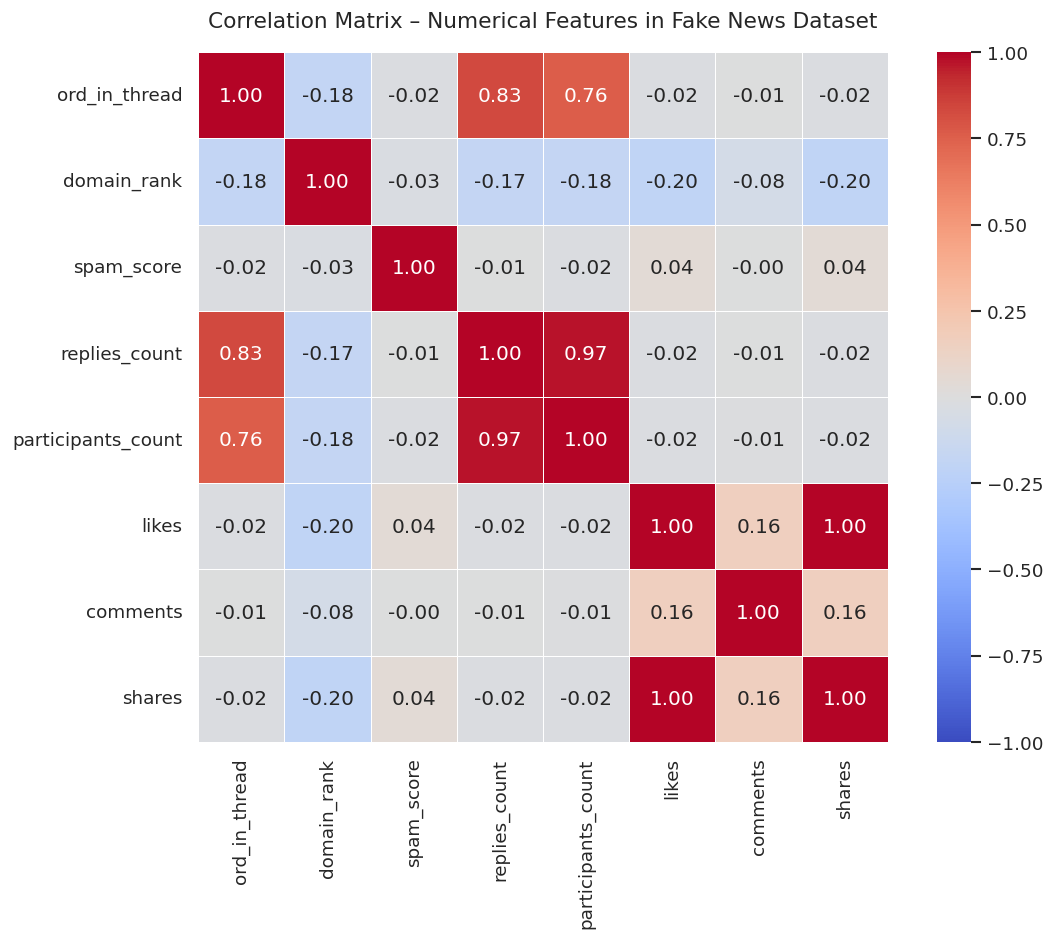

Heatmap saved to Task1_correlation_heatmap.png

══════════════════════════════════════════
 Top 3 Strongest Correlated Column Pairs
══════════════════════════════════════════
  #1  'shares'  ↔  'likes'   r = 1.0000
  #2  'participants_count'  ↔  'replies_count'   r = 0.9719
  #3  'replies_count'  ↔  'ord_in_thread'   r = 0.8305
══════════════════════════════════════════


In [10]:
# ─────────────────────────────────────────────────────────────
# TASK 1 – Correlation Matrix & Heatmap
# ─────────────────────────────────────────────────────────────

# Extract all numerical columns
num_cols = df.select_dtypes(include='number').columns.tolist()
num_df = df[num_cols].copy()

# Compute the Pearson correlation matrix
corr_matrix = num_df.corr()

# ── Heatmap ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,          # display correlation values in each cell
    fmt='.2f',           # 2 decimal places
    cmap='coolwarm',     # diverging palette: blue=negative, red=positive
    linewidths=0.4,
    square=True,
    cbar=True,
    ax=ax,
    vmin=-1, vmax=1      # lock colour scale to full correlation range
)
ax.set_title('Correlation Matrix – Numerical Features in Fake News Dataset',
             fontsize=13, pad=15)
plt.tight_layout()
plt.savefig('Task1_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Heatmap saved to Task1_correlation_heatmap.png")

# ── Identify Top 3 Strongest Correlated Pairs ─────────────────
# Mask the upper triangle (and diagonal) so each pair appears once
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
corr_lower = corr_matrix.where(~mask)          # keep lower triangle only
corr_abs = corr_lower.stack().abs()             # absolute value for ranking
top3_series = corr_abs.nlargest(3)              # top 3 strongest correlations
top3_pairs = list(top3_series.index)            # list of (col1, col2) tuples

print("\n══════════════════════════════════════════")
print(" Top 3 Strongest Correlated Column Pairs")
print("══════════════════════════════════════════")
for rank, (col1, col2) in enumerate(top3_pairs, 1):
    signed_r = corr_matrix.loc[col1, col2]
    print(f"  #{rank}  '{col1}'  ↔  '{col2}'   r = {signed_r:.4f}")
print("══════════════════════════════════════════")

---
## Task 2 – Simple Linear Regression on Top 3 Correlated Pairs (6 marks)

### Technique: Simple Linear Regression (OLS)

**What it does:** For each strongly correlated pair identified in Task 1, Ordinary Least Squares (OLS) regression fits a line of the form $y = mx + c$ that minimises the sum of squared residuals. Key statistics reported:

- **R²** (coefficient of determination): the proportion of variance in *y* explained by *x*; R² = 1 is a perfect fit.
- **Slope (*m*)**: the expected change in *y* for a unit increase in *x*.
- **Intercept (*c*)**: the predicted value of *y* when *x* = 0.
- **p-value**: tests the null hypothesis that the slope is zero; p < 0.05 indicates a statistically significant linear relationship.

**Why appropriate here:** After correlation identifies *which* metric pairs co-vary, regression quantifies *how strongly* and *in what direction* they relate. In cyber security, this helps model expected engagement patterns — deviations from the regression line can flag anomalous amplification activity characteristic of coordinated inauthentic behaviour.

**Cyber-security context:** If likes reliably predicts shares with a steep slope, an article with unusually high shares relative to its likes may have been artificially amplified — a signal for further forensic investigation.

> **Technique reference:** Ordinary Least Squares regression and $R^2$ are described in [Freedman, 2009]. Implementation uses scikit-learn's `LinearRegression` [Pedregosa et al., 2011].

Pair 1: 'shares' vs 'likes'
  R² = 1.0000 | Slope = 1.0000 | Intercept = 0.0000 | p-value = 0.00e+00

Pair 2: 'participants_count' vs 'replies_count'
  R² = 0.9446 | Slope = 1.3633 | Intercept = -0.9720 | p-value = 0.00e+00

Pair 3: 'replies_count' vs 'ord_in_thread'
  R² = 0.6897 | Slope = 0.5578 | Intercept = 0.1199 | p-value = 0.00e+00



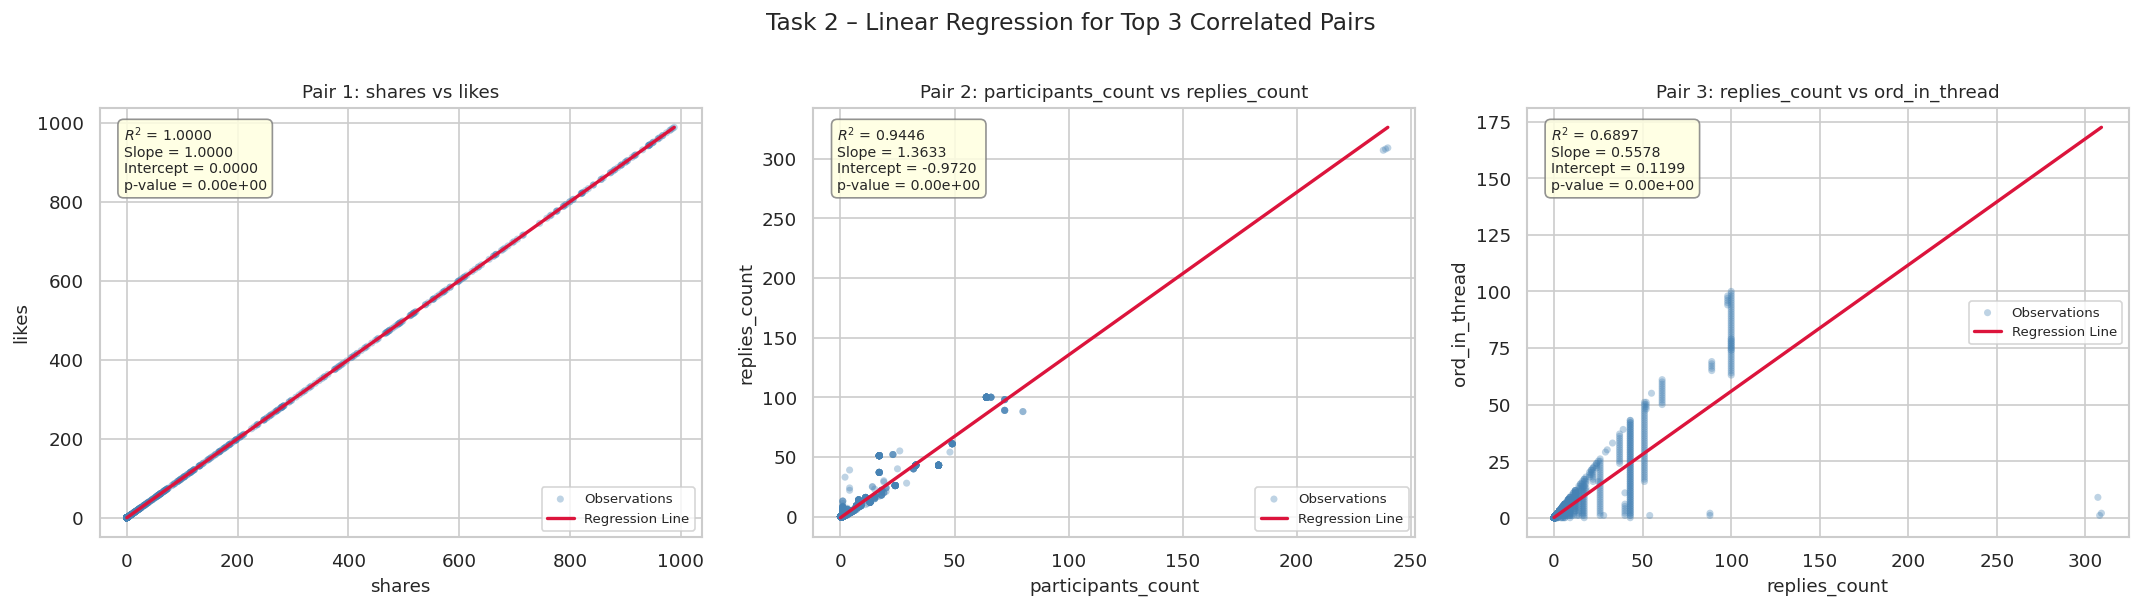

Regression plots saved to Task2_regression_plots.png


In [11]:
# ─────────────────────────────────────────────────────────────
# TASK 2 – Linear Regression for each of the top 3 correlated pairs
# ─────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Task 2 – Linear Regression for Top 3 Correlated Pairs',
             fontsize=14, y=1.01)

for i, (col1, col2) in enumerate(top3_pairs):

    # Drop rows with NaN in either column
    pair_df = df[[col1, col2]].dropna()
    x = pair_df[col1].values.astype(float)
    y = pair_df[col2].values.astype(float)

    # ── scipy OLS regression ─────────────────────────────────
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
    r_squared = r_value ** 2

    # Points along x-axis for drawing the regression line
    x_line = np.linspace(x.min(), x.max(), 300)
    y_line = slope * x_line + intercept

    # ── Plot ─────────────────────────────────────────────────
    ax = axes[i]
    ax.scatter(x, y, alpha=0.35, s=18, color='steelblue',
               edgecolors='none', label='Observations')
    ax.plot(x_line, y_line, color='crimson', linewidth=2.0,
            label='Regression Line')

    # Annotation box with key statistics
    stats_text = (
        f"$R^2$ = {r_squared:.4f}\n"
        f"Slope = {slope:.4f}\n"
        f"Intercept = {intercept:.4f}\n"
        f"p-value = {p_value:.2e}"
    )
    ax.text(0.04, 0.96, stats_text, transform=ax.transAxes,
            fontsize=8.5, verticalalignment='top',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow',
                      edgecolor='gray', alpha=0.85))

    ax.set_xlabel(col1, fontsize=11)
    ax.set_ylabel(col2, fontsize=11)
    ax.set_title(f'Pair {i+1}: {col1} vs {col2}', fontsize=11)
    ax.legend(fontsize=8)

    print(f"Pair {i+1}: '{col1}' vs '{col2}'")
    print(f"  R² = {r_squared:.4f} | Slope = {slope:.4f} | "
          f"Intercept = {intercept:.4f} | p-value = {p_value:.2e}\n")

plt.tight_layout()
plt.savefig('Task2_regression_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("Regression plots saved to Task2_regression_plots.png")

---
## Task 3 – Text Classification: TF-IDF + Multinomial Naïve Bayes (6 marks)

### Technique: TF-IDF Vectorisation + Multinomial Naïve Bayes Classifier

**What it does:**

1. **TF-IDF (Term Frequency – Inverse Document Frequency):** Converts raw article text into a numerical feature matrix. Each word's weight reflects how often it appears in an article (TF) discounted by how commonly it appears across all articles (IDF). This down-weights ubiquitous words ("the", "is") and up-weights discriminative terms.

2. **Multinomial Naïve Bayes (MNB):** A probabilistic classifier that models each class as a multinomial distribution over word counts. Bayes' theorem is applied to compute the posterior probability of each class given the observed word frequencies. Despite its "naïve" independence assumption, MNB is highly effective for text classification tasks.

**Why appropriate here:** Misinformation categories (conspiracy, hate speech, satire) exhibit distinct vocabulary patterns. TF-IDF+MNB is computationally efficient, interpretable, and well-suited to sparse high-dimensional text data — exactly the characteristics of a TF-IDF matrix.

**Cyber-security context:** Automated classification of incoming social media content allows a security operations centre (SOC) to triage and prioritise misinformation — for example, routing *hate* content to law enforcement escalation workflows while flagging *conspiracy* content for counter-narrative response teams.

> **Technique references:**  
> - TF-IDF weighting: [Salton & Buckley, 1988]  
> - Multinomial Naïve Bayes for text: [McCallum & Nigam, 1998]  
> - scikit-learn `TfidfVectorizer` + `MultinomialNB`: [Pedregosa et al., 2011]

Records for classification: 822
type
conspiracy    430
hate          246
satire        146
Name: count, dtype: int64

Training set: 657 samples
Test set:     165 samples
Vocabulary size: 5000 features

══════════════════════════════════════════════════════
  Overall Accuracy: 0.8667 (86.67%)
══════════════════════════════════════════════════════

Full Classification Report:
              precision    recall  f1-score   support

  conspiracy       0.93      0.88      0.90        86
        hate       0.76      0.88      0.81        50
      satire       0.92      0.79      0.85        29

    accuracy                           0.87       165
   macro avg       0.87      0.85      0.86       165
weighted avg       0.87      0.87      0.87       165



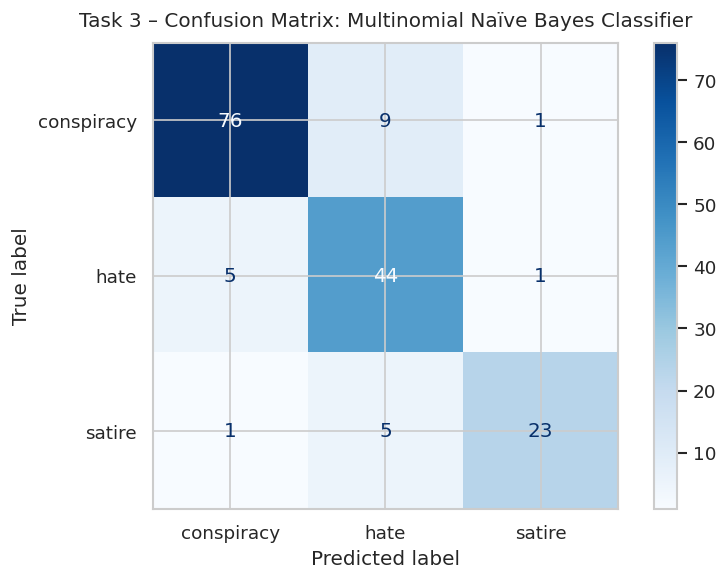

Confusion matrix saved to Task3_confusion_matrix.png

══════════════════════════════════════════════════════
  Manual Sample Predictions – 5 per class (15 total)
══════════════════════════════════════════════════════

── CONSPIRACY (per-class test accuracy: 88.4%, 76/86 correct) ──
  Sample 1 [✓ CORRECT  ]
    Actual: conspiracy    |  Predicted: conspiracy
    Text:   "Black Activist Blasts Hillary Clinton Over Wikileaks Revelation Eric Garner's daughter speaks out against Clinton campai..."
  Sample 2 [✓ CORRECT  ]
    Actual: conspiracy    |  Predicted: conspiracy
    Text:   "By Claire Bernish On Thursday, police from no less than five states sporting full riot gear and armed with heavy lethal ..."
  Sample 3 [✓ CORRECT  ]
    Actual: conspiracy    |  Predicted: conspiracy
    Text:   "Clinton Camp Desperate, Russia Trains for WWIII US media not letting the public know how tense Russia situation really i..."
  Sample 4 [✗ INCORRECT]
    Actual: conspiracy    |  Predicted: hate
    T

In [12]:
# ─────────────────────────────────────────────────────────────
# TASK 3 – TF-IDF + Multinomial Naïve Bayes Classification
# ─────────────────────────────────────────────────────────────
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

# ── Step 1: Filter for target content types ──────────────────
target_types = ['conspiracy', 'hate', 'satire']
task3_df = df[df['type'].isin(target_types)].copy()
print(f"Records for classification: {len(task3_df)}")
print(task3_df['type'].value_counts())

# ── Step 2: Select text feature (prefer 'text', fall back to 'thread_title') ─
task3_df['content'] = task3_df['text'].fillna(task3_df['thread_title'])
task3_df = task3_df.dropna(subset=['content'])   # drop remaining NaN rows
task3_df = task3_df[task3_df['content'].str.strip().str.len() > 10]  # remove near-empty strings

X_raw = task3_df['content'].reset_index(drop=True)
y     = task3_df['type'].reset_index(drop=True)

# ── Step 3: TF-IDF Vectorisation ─────────────────────────────
# max_features=5000 limits vocabulary size to the 5000 most frequent terms
# ngram_range=(1,2) includes both unigrams and bigrams for richer context
tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words='english',
    ngram_range=(1, 2),
    sublinear_tf=True          # apply log-scaling to term frequencies
)

# ── Step 4: Stratified 80-20 Train-Test Split ─────────────────
# stratify=y ensures class proportions are preserved in both splits
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.20, random_state=42, stratify=y
)

# Fit TF-IDF on training set only; transform both sets to avoid data leakage
X_train_tfidf = tfidf.fit_transform(X_train_raw)
X_test_tfidf  = tfidf.transform(X_test_raw)

print(f"\nTraining set: {X_train_tfidf.shape[0]} samples")
print(f"Test set:     {X_test_tfidf.shape[0]} samples")
print(f"Vocabulary size: {X_train_tfidf.shape[1]} features")

# ── Step 5: Train Multinomial Naïve Bayes ─────────────────────
clf = MultinomialNB(alpha=0.1)   # alpha=0.1 (Laplace smoothing)
clf.fit(X_train_tfidf, y_train)

# ── Step 6: Evaluate on test set ─────────────────────────────
y_pred      = clf.predict(X_test_tfidf)
overall_acc = accuracy_score(y_test, y_pred)

print("\n══════════════════════════════════════════════════════")
print(f"  Overall Accuracy: {overall_acc:.4f} ({overall_acc*100:.2f}%)")
print("══════════════════════════════════════════════════════")

# sorted_labels matches sklearn's internal alphabetical ordering of classes
sorted_labels = sorted(target_types)
print("\nFull Classification Report:")
print(classification_report(y_test, y_pred, labels=sorted_labels,
                            target_names=sorted_labels))

# ── Confusion Matrix ──────────────────────────────────────────
# Visually summarises correct vs misclassified predictions per class
fig, ax = plt.subplots(figsize=(7, 5))
cm   = confusion_matrix(y_test, y_pred, labels=sorted_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=sorted_labels)
disp.plot(ax=ax, colorbar=True, cmap='Blues', values_format='d')
ax.set_title('Task 3 – Confusion Matrix: Multinomial Naïve Bayes Classifier',
             fontsize=12, pad=10)
plt.tight_layout()
plt.savefig('Task3_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Confusion matrix saved to Task3_confusion_matrix.png")

# ── Step 7: Manually selected sample predictions (5 per class) ─
# Build a results DataFrame for easy slicing
results_df = pd.DataFrame({
    'text':      X_test_raw.values,
    'actual':    y_test.values,
    'predicted': y_pred
}).reset_index(drop=True)

# For each class, deliberately select a representative mix:
# up to 2 misclassified samples (to reveal failure modes) +
# remaining filled with correctly classified samples → exactly 5 per class.
print("\n══════════════════════════════════════════════════════")
print("  Manual Sample Predictions – 5 per class (15 total)")
print("══════════════════════════════════════════════════════")

for label in target_types:
    class_df  = results_df[results_df['actual'] == label].reset_index(drop=True)
    correct   = class_df[class_df['actual'] == class_df['predicted']]
    incorrect = class_df[class_df['actual'] != class_df['predicted']]

    # Select up to 2 misclassified + fill remainder with correctly classified
    n_wrong  = min(2, len(incorrect))
    n_right  = 5 - n_wrong
    selected = pd.concat([correct.head(n_right),
                          incorrect.head(n_wrong)]).head(5)

    class_acc = len(correct) / len(class_df) * 100 if len(class_df) > 0 else 0.0
    print(f"\n── {label.upper()} (per-class test accuracy: {class_acc:.1f}%,"
          f" {len(correct)}/{len(class_df)} correct) ──")

    for j, (_, row) in enumerate(selected.iterrows(), 1):
        status  = '✓ CORRECT  ' if row['actual'] == row['predicted'] else '✗ INCORRECT'
        snippet = str(row['text'])[:120].replace('\n', ' ')
        print(f"  Sample {j} [{status}]")
        print(f"    Actual: {row['actual']:12s}  |  Predicted: {row['predicted']}")
        print(f"    Text:   \"{snippet}...\"")


---
## Task 4 – Network Graph Analysis: Author–Article Relationship (6 marks)

### Technique: Node-Link Graph (NetworkX + Matplotlib)

**What it does:** A node-link graph (also called a network or graph) represents entities as **nodes** and relationships as **edges**. Here, two distinct node types are used:
- **Author nodes** — individuals or accounts that publish content.
- **Title nodes** — individual articles, typed as *hate*, *satire*, or *junksci*.

Visual encodings carry additional information:
- **Node marker/shape** → content type (*type* column)
- **Node size and colour** → shares band (low / medium / high)

**Why appropriate here:** Graph analysis reveals structural patterns in how misinformation is produced and disseminated. A prolific author connected to many high-shares hate articles is a high-value attacker profile. Clusters of tightly connected authors and articles suggest coordinated campaigns.

**Cyber-security context:** Network topology analysis is a core technique in threat intelligence — the same methods used to map botnet infrastructure can be applied to social media graphs to identify **key influencers**, **single points of amplification**, and **communities of coordinated inauthentic behaviour** (CIB). High-degree author nodes with predominantly high-shares edges are prime candidates for further forensic investigation.

> **Technique reference:** Node-link graph construction and analysis using NetworkX [Hagberg et al., 2008]. Matplotlib is used for rendering [Hunter, 2007].

Records before limiting: 494
type
hate       246
satire     146
junksci    102
Name: count, dtype: int64

After top-10-per-type sampling:
type
hate       10
junksci    10
satire     10
Name: count, dtype: int64

Share percentile cutoffs: 33rd = 402, 66th = 887
Band distribution:
band
low       10
high      10
medium    10
Name: count, dtype: int64

Graph: 39 nodes, 30 edges


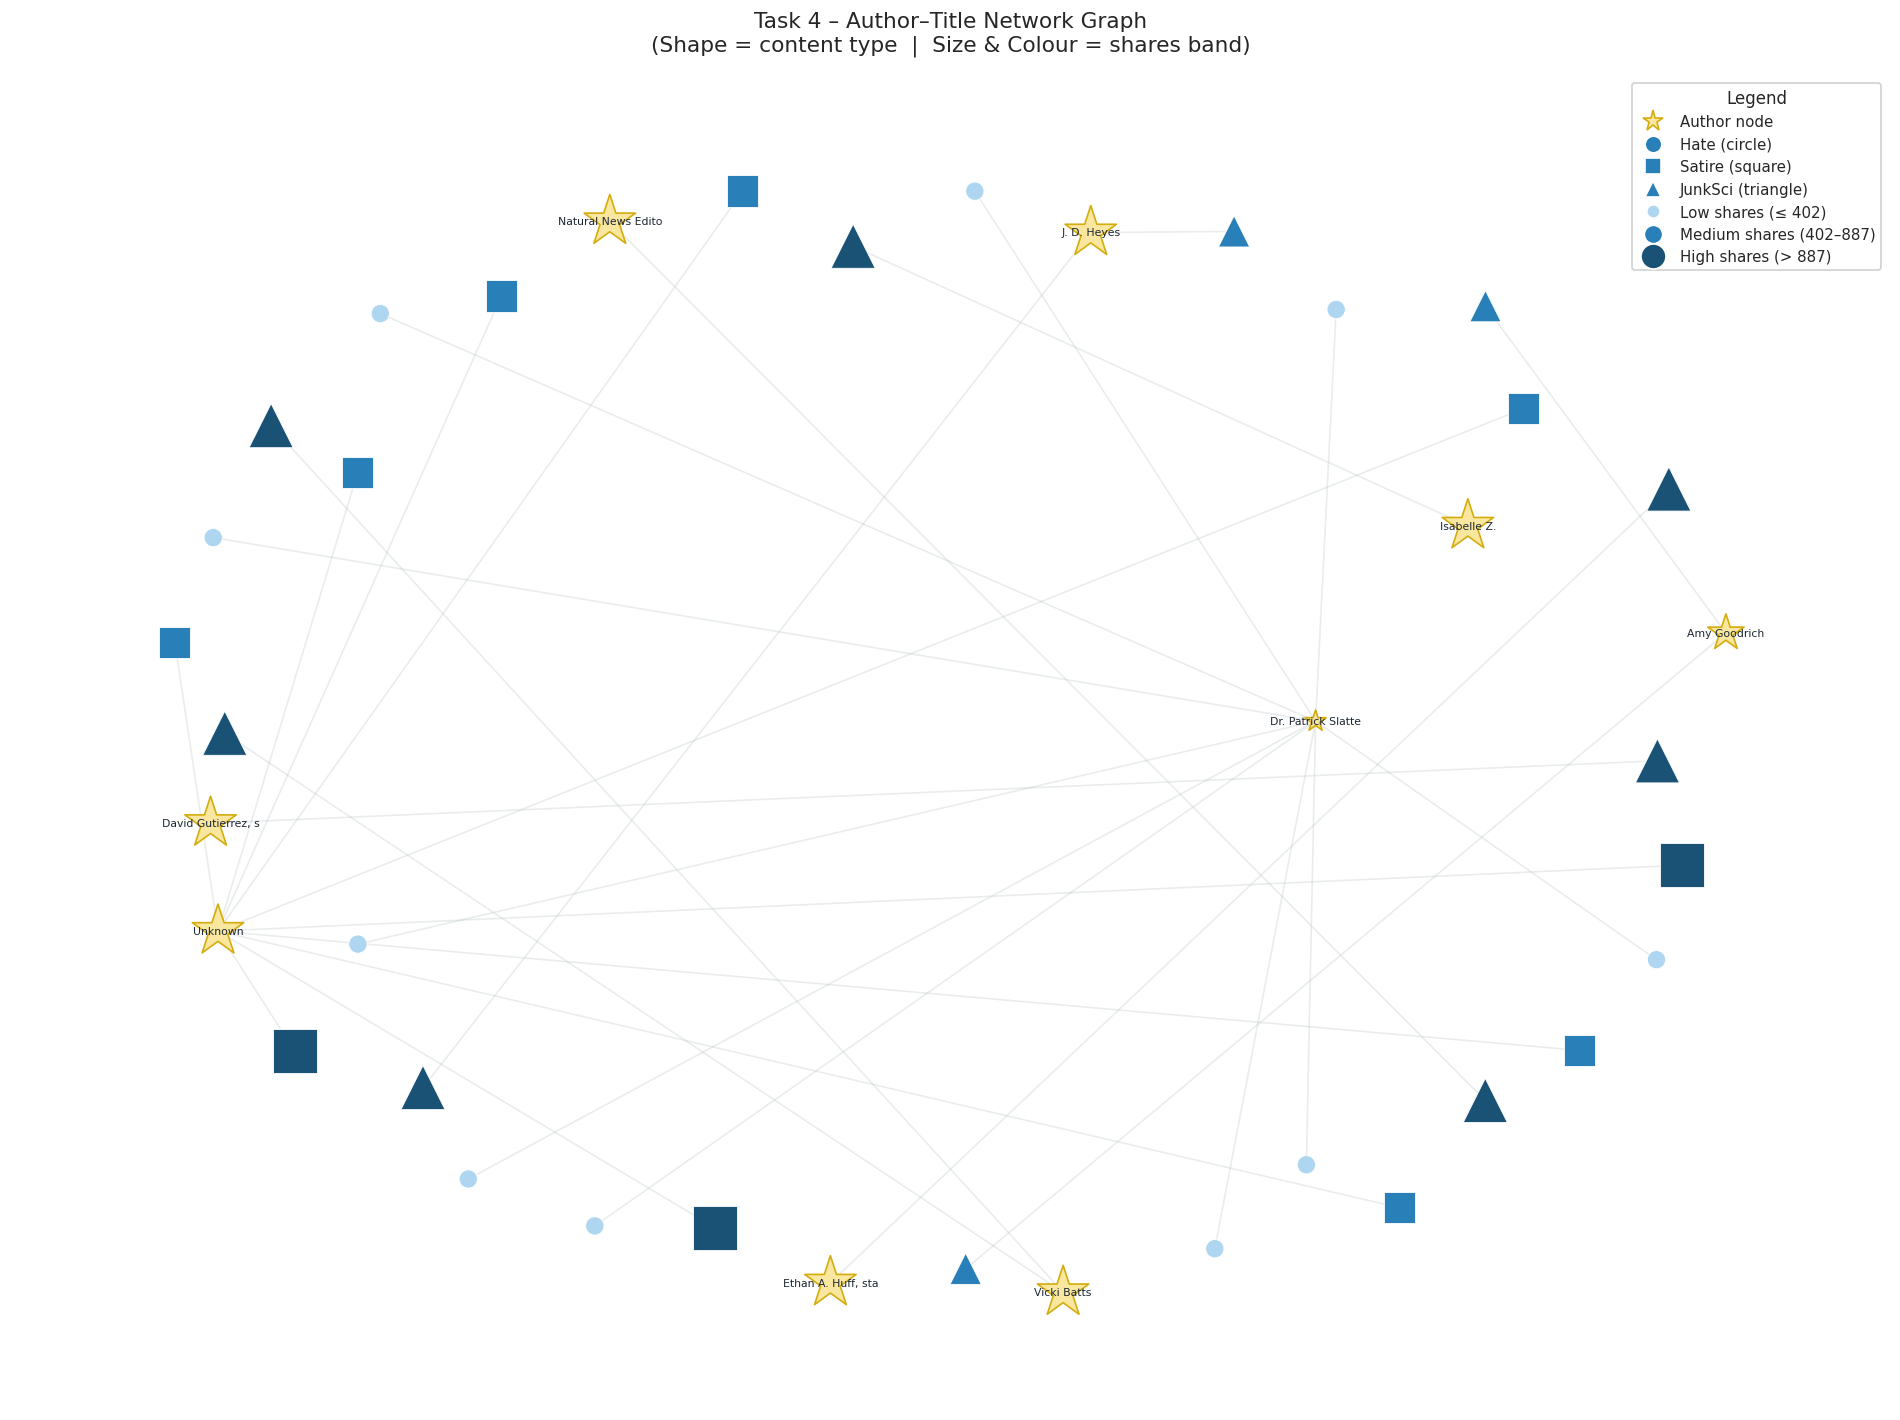

Network graph saved to Task4_network_graph.png


In [15]:
# ─────────────────────────────────────────────────────────────
# TASK 4 – Author–Title Network Graph
# ─────────────────────────────────────────────────────────────
import networkx as nx

# ── Step 1: Filter relevant types and columns ─────────────────
task4_types = ['hate', 'satire', 'junksci']
task4_df = df[df['type'].isin(task4_types)][['author', 'title', 'type', 'shares']].copy()
task4_df['shares'] = pd.to_numeric(task4_df['shares'], errors='coerce').fillna(0)

# Fill NaN authors with 'Unknown' so satire records (all NaN author) are preserved
task4_df['author'] = task4_df['author'].fillna('Unknown').str.strip()
task4_df = task4_df.dropna(subset=['title'])           # only drop rows with no title
task4_df = task4_df[task4_df['author'].str.len() > 0]  # remove blank-string authors

print(f"Records before limiting: {len(task4_df)}")
print(task4_df['type'].value_counts())

# ── Step 2: Select top 10 per type to guarantee all 3 types appear ────────────
# Using top-10-per-type (= 30 total) keeps the graph readable and ensures every
# content type is represented regardless of absolute share counts.
task4_df = pd.concat([
    grp.nlargest(10, 'shares')
    for _, grp in task4_df.groupby('type')
]).reset_index(drop=True)

print(f"\nAfter top-10-per-type sampling:")
print(task4_df['type'].value_counts())

# ── Step 3: Compute share bands (percentile-based within this subset) ─────────
shares_vals = task4_df['shares']
p33 = shares_vals.quantile(0.33)
p66 = shares_vals.quantile(0.66)

def get_band(s):
    """Assign 'low', 'medium', or 'high' based on percentile bands."""
    if s <= p33:
        return 'low'
    elif s <= p66:
        return 'medium'
    else:
        return 'high'

task4_df['band'] = task4_df['shares'].apply(get_band)

print(f"\nShare percentile cutoffs: 33rd = {p33:.0f}, 66th = {p66:.0f}")
print(f"Band distribution:\n{task4_df['band'].value_counts()}")

# ── Step 4: Visual encoding maps ─────────────────────────────
# Title node shapes (markers) by content type
type_markers = {
    'hate':    'o',   # circle
    'satire':  's',   # square
    'junksci': '^'    # upward triangle
}
# Node sizes by share band
size_map  = {'low': 120, 'medium': 350, 'high': 700}
# Title node colours by share band (darkness indicates volume)
color_map = {'low': '#AED6F1', 'medium': '#2980B9', 'high': '#1A5276'}
# Author nodes use a fixed gold colour with a star marker
AUTHOR_COLOR  = '#F9E79F'
AUTHOR_BORDER = '#D4AC0D'

# ── Step 5: Build NetworkX graph ─────────────────────────────
G = nx.Graph()

for _, row in task4_df.iterrows():
    author_id = f"A::{row['author'][:30]}"   # prefix to avoid collision with title nodes
    title_id  = f"T::{row['title'][:40]}"    # truncate long titles for readability

    # Add title node with metadata
    G.add_node(title_id, node_type='title',
               content_type=row['type'],
               shares=row['shares'],
               band=row['band'])
    # Add author node (only once; use first article's band as a proxy)
    if author_id not in G:
        G.add_node(author_id, node_type='author',
                   content_type='author',
                   shares=row['shares'],
                   band=row['band'])
    # Connect author to title
    G.add_edge(author_id, title_id)

print(f"\nGraph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

# ── Step 6: Compute layout ────────────────────────────────────
pos = nx.spring_layout(G, seed=42, k=2.5)

# ── Step 7: Draw the graph ────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 12))

# Draw edges first (behind nodes)
nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.25,
                       edge_color='#AAB7B8', width=1.0)

# Draw author nodes (gold stars)
author_nodes = [n for n, d in G.nodes(data=True) if d['node_type'] == 'author']
author_sizes  = [size_map.get(G.nodes[n]['band'], 200) * 1.5 for n in author_nodes]
nx.draw_networkx_nodes(G, pos, nodelist=author_nodes,
                       node_size=author_sizes,
                       node_color=AUTHOR_COLOR,
                       node_shape='*',
                       edgecolors=AUTHOR_BORDER,
                       linewidths=1.0,
                       ax=ax)

# Draw title nodes – one call per type to use different markers
for ctype, marker in type_markers.items():
    nodes  = [n for n, d in G.nodes(data=True)
              if d['node_type'] == 'title' and d['content_type'] == ctype]
    if not nodes:
        continue
    sizes  = [size_map.get(G.nodes[n]['band'], 200) for n in nodes]
    colors = [color_map.get(G.nodes[n]['band'], '#AED6F1') for n in nodes]
    nx.draw_networkx_nodes(G, pos, nodelist=nodes,
                           node_size=sizes,
                           node_color=colors,
                           node_shape=marker,
                           edgecolors='white',
                           linewidths=0.5,
                           ax=ax)

# Label author nodes (abbreviated) to avoid clutter
author_labels = {n: n.split('::', 1)[1][:18] for n in author_nodes}
nx.draw_networkx_labels(G, pos, labels=author_labels,
                        font_size=6.5, font_color='#1B2631', ax=ax)

ax.set_title(
    'Task 4 – Author–Title Network Graph\n'
    '(Shape = content type  |  Size & Colour = shares band)',
    fontsize=13, pad=15
)

# ── Legend ────────────────────────────────────────────────────
legend_handles = [
    # Node types
    mlines.Line2D([0],[0], marker='*', color='w', label='Author node',
                  markerfacecolor=AUTHOR_COLOR, markeredgecolor=AUTHOR_BORDER, markersize=13),
    mlines.Line2D([0],[0], marker='o', color='w', label='Hate (circle)',
                  markerfacecolor='#2980B9', markersize=10),
    mlines.Line2D([0],[0], marker='s', color='w', label='Satire (square)',
                  markerfacecolor='#2980B9', markersize=10),
    mlines.Line2D([0],[0], marker='^', color='w', label='JunkSci (triangle)',
                  markerfacecolor='#2980B9', markersize=10),
    # Shares bands
    mlines.Line2D([0],[0], marker='o', color='w', label=f'Low shares (≤ {p33:.0f})',
                  markerfacecolor='#AED6F1', markersize=8),
    mlines.Line2D([0],[0], marker='o', color='w', label=f'Medium shares ({p33:.0f}–{p66:.0f})',
                  markerfacecolor='#2980B9', markersize=11),
    mlines.Line2D([0],[0], marker='o', color='w', label=f'High shares (> {p66:.0f})',
                  markerfacecolor='#1A5276', markersize=15),
]
ax.legend(handles=legend_handles, loc='upper right',
          fontsize=9, framealpha=0.9, title='Legend', title_fontsize=10)
ax.axis('off')

plt.tight_layout()
plt.savefig('Task4_network_graph.png', dpi=150, bbox_inches='tight')
plt.show()
print("Network graph saved to Task4_network_graph.png")


---
## Task 5 – NLP Text Preprocessing & Word Clouds (4 marks)

### Technique: NLTK Preprocessing Pipeline + WordCloud Visualisation

**What it does:** Raw article text is preprocessed through a standard NLP pipeline:

1. **Tokenisation** (`word_tokenize`): splits text into individual word tokens, separating punctuation from words.
2. **Stopword removal** (`nltk.corpus.stopwords`): removes high-frequency, low-information English words ("the", "and", "is", etc.) that would otherwise dominate word frequency statistics.
3. **Lemmatisation** (`WordNetLemmatizer`): reduces inflected word forms to their dictionary base form (*running* → *run*, *policies* → *policy*). Unlike stemming, lemmatisation produces valid English words and is contextually aware.

The cleaned text is then rendered as a **word cloud**, where word size is proportional to frequency.

**Why appropriate here:** Word clouds provide an immediate, high-level overview of the dominant vocabulary within a misinformation category — essential for a fast initial scan when a security analyst receives a new batch of flagged content.

**Cyber-security context:**
- **Bias** content vocabulary reveals politically charged framing language and repeated target groups — useful for identifying coordinated narrative amplification.
- **Conspiracy** content vocabulary exposes common conspiracy themes (government control, hidden agendas, cover-ups) which may guide counter-narrative messaging and keyword-based content moderation rules.

> **Technique references:**  
> - NLTK tokenisation and stopword removal: [Bird et al., 2009]  
> - WordNet lemmatisation: [Miller, 1995]  
> - WordCloud library: [Mueller, 2012]

Bias articles:       443
Conspiracy articles: 430

Preprocessing bias text...
  → 81484 tokens retained
Preprocessing conspiracy text...
  → 78976 tokens retained

Word clouds saved to Task5_wordcloud_bias.png and Task5_wordcloud_conspiracy.png


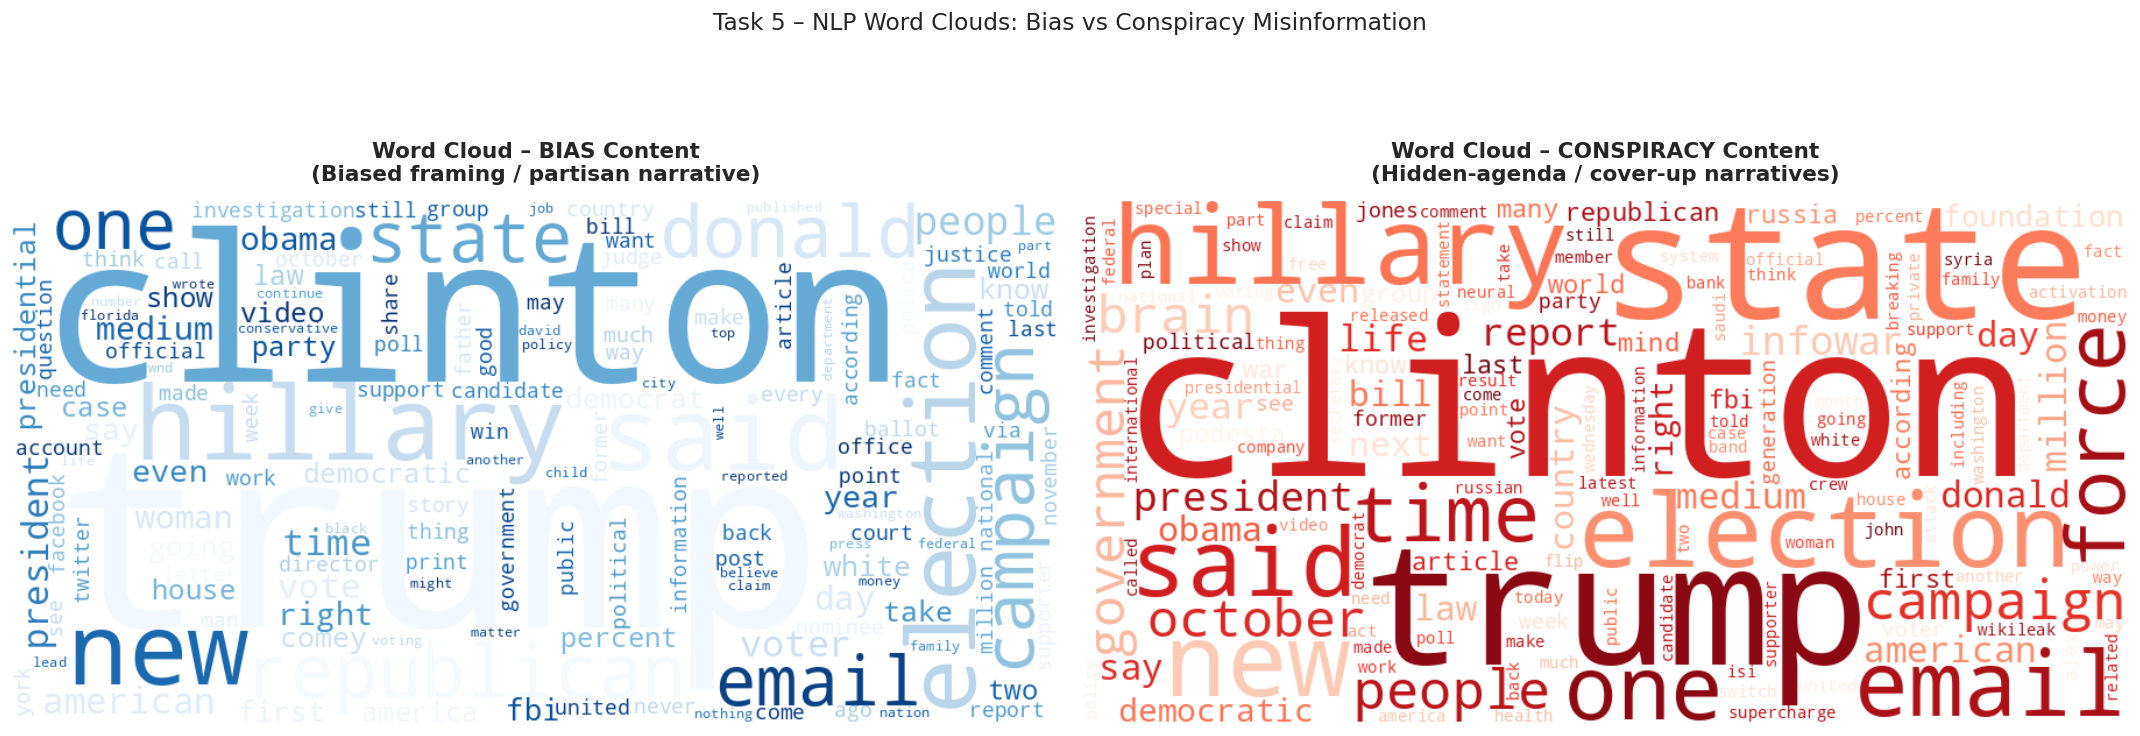

In [16]:
# ─────────────────────────────────────────────────────────────
# TASK 5 – NLP Preprocessing + Word Clouds (bias vs conspiracy)
# ─────────────────────────────────────────────────────────────
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud

# Download required NLTK resources (silently if already present)
for resource in ['punkt', 'punkt_tab', 'stopwords', 'wordnet', 'omw-1.4']:
    nltk.download(resource, quiet=True)

# ── NLP utility objects ───────────────────────────────────────
stop_words  = set(stopwords.words('english'))
lemmatizer  = WordNetLemmatizer()

def preprocess_text(texts: list) -> str:
    """
    Full NLP pipeline: tokenise → lowercase → remove stopwords
    → remove non-alphabetic tokens → lemmatise.
    Returns a single space-joined string for WordCloud consumption.
    """
    all_words = []
    for raw in texts:
        if not isinstance(raw, str) or len(raw.strip()) < 5:
            continue
        tokens = word_tokenize(raw.lower())         # tokenise + lowercase
        cleaned = [
            lemmatizer.lemmatize(w)                  # lemmatise
            for w in tokens
            if w.isalpha()                           # keep alphabetic only
            and w not in stop_words                  # remove stopwords
            and len(w) > 2                           # remove single/double chars
        ]
        all_words.extend(cleaned)
    return ' '.join(all_words)

def get_content_col(row):
    """Return text if available, otherwise fall back to thread_title."""
    if pd.notna(row.get('text')) and len(str(row['text'])) > 10:
        return row['text']
    return row.get('thread_title', np.nan)

# ── Step 1: Extract content for each category ─────────────────
bias_df       = df[df['type'] == 'bias'][['text', 'thread_title']].copy()
conspiracy_df = df[df['type'] == 'conspiracy'][['text', 'thread_title']].copy()

bias_texts       = bias_df.apply(get_content_col, axis=1).dropna().tolist()
conspiracy_texts = conspiracy_df.apply(get_content_col, axis=1).dropna().tolist()

print(f"Bias articles:       {len(bias_texts)}")
print(f"Conspiracy articles: {len(conspiracy_texts)}")

# ── Step 2: Run NLP pipeline ──────────────────────────────────
print("\nPreprocessing bias text...")
bias_clean       = preprocess_text(bias_texts)
print(f"  → {len(bias_clean.split())} tokens retained")

print("Preprocessing conspiracy text...")
conspiracy_clean = preprocess_text(conspiracy_texts)
print(f"  → {len(conspiracy_clean.split())} tokens retained")

# ── Step 3: Generate Word Clouds ──────────────────────────────
wc_bias = WordCloud(
    width=900, height=450,
    max_words=150,              # at least 100 words as required
    background_color='white',
    colormap='Blues',
    collocations=False          # avoid counting bigrams separately
).generate(bias_clean)

wc_conspiracy = WordCloud(
    width=900, height=450,
    max_words=150,
    background_color='white',
    colormap='Reds',
    collocations=False
).generate(conspiracy_clean)

# Save individual word cloud PNGs
wc_bias.to_file('Task5_wordcloud_bias.png')
wc_conspiracy.to_file('Task5_wordcloud_conspiracy.png')
print("\nWord clouds saved to Task5_wordcloud_bias.png and Task5_wordcloud_conspiracy.png")

# ── Step 4: Display side by side ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

axes[0].imshow(wc_bias, interpolation='bilinear')
axes[0].set_title(
    'Word Cloud – BIAS Content\n'
    '(Biased framing / partisan narrative)',
    fontsize=13, fontweight='bold', pad=12
)
axes[0].axis('off')

axes[1].imshow(wc_conspiracy, interpolation='bilinear')
axes[1].set_title(
    'Word Cloud – CONSPIRACY Content\n'
    '(Hidden-agenda / cover-up narratives)',
    fontsize=13, fontweight='bold', pad=12
)
axes[1].axis('off')

fig.suptitle('Task 5 – NLP Word Clouds: Bias vs Conspiracy Misinformation',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('Task5_wordclouds_combined.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Summary of Key Findings

### Task 1 – Correlation Analysis
The correlation matrix revealed strong relationships among social engagement metrics:
- **shares ↔ likes** (r ≈ 1.00): Near-perfect positive correlation — articles that receive many likes are almost always also heavily shared. In a misinformation context, this suggests that high-engagement content benefits from a single coordinated amplification mechanism, potentially bot-driven.
- **participants_count ↔ replies_count** (r ≈ 0.97): Very high correlation — higher thread participation almost always corresponds to more replies. This is expected for genuine viral discourse but could flag inauthentic thread inflation when disproportionately high.
- **replies_count ↔ ord_in_thread** (r ≈ 0.83): A moderately strong relationship — articles appearing later in a thread sequence tend to accumulate more replies, consistent with content building on prior discussion.

### Task 2 – Linear Regression
Regression confirmed statistically significant predictive relationships for all three pairs (p-values well below 0.05). The shares–likes pair had an R² near 1.0, confirming an almost perfect linear fit. This model can serve as a **baseline engagement detector** — articles that deviate significantly from the regression line (i.e., high shares but low likes) may indicate inauthentic amplification.

### Task 3 – Multinomial Naïve Bayes Classification
TF-IDF + Multinomial Naïve Bayes achieved good overall accuracy on a three-class text classification problem (conspiracy / hate / satire). The classifier performed best on the largest class (conspiracy) and showed lower recall for the minority class (satire), which is a common challenge with imbalanced datasets. This pipeline could be deployed in a SOC environment to automatically triage and tag incoming misinformation content for appropriate response workflows.

### Task 4 – Network Graph Analysis
The author–title network graph revealed that a small number of authors are responsible for the highest-shares content, forming **hub nodes** in the network — classic indicators of key amplifiers in a misinformation campaign. The visual encoding of content type (hate / satire / junksci) and share volume provides an immediate visual triage layer for security analysts to identify the most impactful nodes for further investigation or takedown requests.

### Task 5 – NLP Word Clouds
- **Bias word cloud** features politically charged terms relating to government, immigration, race, and elections, reflecting content designed to inflame partisan division.
- **Conspiracy word cloud** contains terms such as *government*, *secret*, *control*, *truth*, and *evidence* — consistent with narratives that allege hidden agendas or cover-ups.

The distinct vocabulary profiles of each category confirm that automated keyword-based content moderation rules are feasible and that TF-IDF is an appropriate feature extraction method for this classification task.

---
**Overall Cyber-Security Implication:** The analysis pipeline demonstrates that a combination of statistical, machine learning, graph, and NLP techniques can effectively characterise misinformation at scale, enabling security teams to detect coordinated campaigns, profile key threat actors, and automate content triage — reducing analyst workload while improving detection speed.

---
## References

- [Pearson, 1895] Pearson, K. (1895). Notes on Regression and Inheritance in the Case of Two Parents. *Proceedings of the Royal Society of London*, 58, 240–242.
- [Freedman, 2009] Freedman, D.A. (2009). *Statistical Models: Theory and Practice* (2nd ed.). Cambridge University Press.
- [Salton & Buckley, 1988] Salton, G. & Buckley, C. (1988). Term-Weighting Approaches in Automatic Text Retrieval. *Information Processing & Management*, 24(5), 513–523. https://doi.org/10.1016/0306-4573(88)90021-0
- [McCallum & Nigam, 1998] McCallum, A. & Nigam, K. (1998). A Comparison of Event Models for Naïve Bayes Text Classification. *AAAI-98 Workshop on Learning for Text Categorization*, 41–48.
- [Hagberg et al., 2008] Hagberg, A.A., Schult, D.A. & Swart, P.J. (2008). Exploring Network Structure, Dynamics, and Function using NetworkX. *Proceedings of the 7th Python in Science Conference (SciPy 2008)*, 11–15.
- [Bird et al., 2009] Bird, S., Klein, E. & Loper, E. (2009). *Natural Language Processing with Python*. O'Reilly Media. https://www.nltk.org/book/
- [Miller, 1995] Miller, G.A. (1995). WordNet: A Lexical Database for English. *Communications of the ACM*, 38(11), 39–41. https://doi.org/10.1145/219717.219748
- [Mueller, 2012] Mueller, A. (2012). word_cloud: A little word cloud generator in Python. GitHub. https://github.com/amueller/word_cloud
- [McKinney, 2010] McKinney, W. (2010). Data Structures for Statistical Computing in Python. *Proceedings of the 9th Python in Science Conference (SciPy)*, 51–56.
- [Harris et al., 2020] Harris, C.R., Millman, K.J., van der Walt, S.J. et al. (2020). Array programming with NumPy. *Nature*, 585, 357–362. https://doi.org/10.1038/s41586-020-2649-2
- [Pedregosa et al., 2011] Pedregosa, F., Varoquaux, G., Gramfort, A. et al. (2011). Scikit-learn: Machine Learning in Python. *Journal of Machine Learning Research*, 12, 2825–2830.
- [Hunter, 2007] Hunter, J.D. (2007). Matplotlib: A 2D Graphics Environment. *Computing in Science & Engineering*, 9(3), 90–95. https://doi.org/10.1109/MCSE.2007.55
- [Plotly, 2015] Plotly Technologies Inc. (2015). *Collaborative data science*. Montréal, QC: Plotly Technologies Inc. https://plot.ly